In [46]:
import importlib
import os
import pickle
from pathlib import Path
import re
import datetime

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from behave_analysis.visualize.visualize_utils import open_tracking_data
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.analyze.single_trial import preprocess_regression
from behave_analysis.analyze.single_trial import single_trial_regression
from behave_analysis.analyze.single_trial.single_trial_regression import SingleTrialRegression
from behave_analysis.analyze.single_trial.preprocess_regression import PreprocessSingleTrialRegression
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_shelt_4mar


## Import data

In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,JAL7_30apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

# Sessions to consider

In [3]:
# JAL6
experiments_objects = [JAL6_shelt_4mar, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may]

In [4]:
session_names = ["JAL6_4th_March", "JAL6_18th_March", "JAL6_21st_March", "JAL6_25th_March", "JAL6_28th_March",
                 "JAL3_25th_Aug", "JAL3_1st_Sept", "JAL3_4th_Sept", "JAL3_7th_Sept",
                 "JAL005_8th_Sept", "JAL005_21st_Sept",
                    "JAL7_9th_April", "JAL7_16th_April", "JAL7_22nd_March", "JAL7_12th_March", "JAL7_23rd_April", "JAL7_30th_April",
                    "JAL8_25th_April", "JAL8_29th_April", "JAL8_3rd_May", "JAL8_10th_May", "JAL8_14th_May", "JAL8_21st_May"]

In [152]:
# JAL6
experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

session_names = ["JAL4_3rd_Sept", "JAL4_19th_Sept", "JAL4_28th_Aug", "JAL4_11th_Sept"]

In [137]:
c_type = "good"
dir = make_directory(r"Z:\Jasmine_Laurence\single_trial_overview")
dir = Path(dir)
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]

# Loop through sessions and generate R2 scores across all homings all conditions

In [153]:
importlib.reload(preprocess_regression)
importlib.reload(single_trial_regression)

for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    
    # Define paths
    video_and_spike_data_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "good_video_spike_count_df.parquet")
    homing_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "homings", "homings_obj.pkl")
    escape_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "escapes", "escapes_obj.pkl")

    # Load data
    try:
        video_df = pl.read_csv(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" "full_video_dataframe.csv")
        with open(homing_path, "rb") as hf:
                homings_object = pickle.load(hf) 
                
        video_and_spike_data = pl.read_parquet(video_and_spike_data_path)
        frame_by_cluster_matrix = np.load(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" + "frame_by_" + c_type + "_cluster_matrix.npy")
        tracking_data = open_tracking_data(loaded_session)
        with open(escape_path, "rb") as ef:
                escape_object = pickle.load(ef)
        cluster_Ids = np.load(str(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "/" + c_type + "_cluster_Ids.npy"))
    
    except FileNotFoundError:
        print("One of the files was not found")
    
    # If there is no barrier in this session hard code it based on a prior session
    if not "barrier_loc" in tracking_data.keys():
        tracking_data["barrier_loc"] = [[224, 515], [797, 512], [510, 513]]
    
    for condition in conditions:
        # Run analysis
        pp_single_trial_obj = PreprocessSingleTrialRegression(
            video_df=video_df,
            homings_obj=homings_object,
            frame_by_cluster_matrix=frame_by_cluster_matrix,
            save_path=dir,
            velocity_data=tracking_data["avg_Velocity"],
            similar_homings=False,
            barrier_location=tracking_data["barrier_loc"],
            shelter_location=tracking_data["shelter_loc"],
            escape_object=escape_object,
            remove_escapes=False,
            save_plots=False,
            condition=condition)
        
        if len(pp_single_trial_obj.design_matrix) == 0:
            print("No trials for this condition")
            continue
        
        # Make sure there are enough homings in this condition 
        if pp_single_trial_obj.condition_per_homing.count(condition) < 10:
            print("Less than 10 trials for this condition")
            continue
                
        SingleTrialRegression(
            design_matrix=pp_single_trial_obj.design_matrix,
            save_path=dir,
            dependents_df=pp_single_trial_obj.targets_df,
            tracking_data=tracking_data,
            homing_list=pp_single_trial_obj.homing_list,
            spike_homing_list=pp_single_trial_obj.spike_data_per_homing,
            condition_per_homing=pp_single_trial_obj.condition_per_homing,
            cluster_ids=cluster_Ids,
            initial_directions=None,
            conversion_from_left_right_to_pre_post_flip=pp_single_trial_obj.convert_left_right_to_pre_post_flip,
            session_name=session_names[i],
            condition=condition)
                

2024-10-03 16:52:34.617 | INFO     | behave_analysis.analyze.single_trial.preprocess_regression:__init__:53 - Initializing the single trial regression preprocessing object
2024-10-03 16:52:34.619 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:15 - The barrier location pre flip is [181, 518] and post flip is [860, 514]
2024-10-03 16:52:34.619 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:17 - The barrier preflip location is the left edge
2024-10-03 16:52:34.787 | SUCCESS  | behave_analysis.analyze.single_trial.tests:check_index_is_valid:81 - All tests passed for the compute_predictor function
2024-10-03 16:52:34.861 | SUCCESS  | behave_analysis.analyze.single_trial.preprocess_regression:__init__:113 - The single trial regression preprocessing object has been initialized
2024-10-03 16:52:34.879 | INFO     | behave_analysis.analyze.single_trial.single_trial_regression:__ini

# Load by condition

In [9]:
def load_r2_data(load_dir, condition):
    """
    Loads .pickle files from a directory based on a specific pattern condition.
    
    Args:
    - load_dir (str): Directory path where the .pickle files are stored.
    - condition (str): The condition pattern to match (e.g., "shelter_only", "barrier_pre_flip", "barrier_post_flip").
    
    Returns:
    - file_names (list): List of file names that match the condition.
    - r2_data (dict): Dictionary of r2 data loaded from matching files.
    """
    
    # Initialize storage for file names and r2 data
    file_names = []
    r2_data = {}

    # Create a dynamic pattern based on the condition
    pattern = fr'^(.*)_{condition}_r2'

    # Loop through files in the specified directory
    for file in os.listdir(load_dir):
        match = re.match(pattern, file)
        if match:
            extracted_part = match.group(1)
            file_names.append(extracted_part)
            
            # Load the .pickle files
            if file.endswith(".pickle"):
                with open(os.path.join(load_dir, file), "rb") as f:
                    data = pickle.load(f)
                    r2_data[extracted_part] = data
    
    return file_names, r2_data

## Across mice for each condition

In [147]:
load_dir = r"Z:\Jasmine_Laurence\single_trial_overview\r2_scores"
con_dict = {}
for condition in conditions:
    file_names, r2_data = load_r2_data(load_dir, condition)
    con_dict[condition] = pd.DataFrame(r2_data).T
con_dict["shelter_only"]

,frames,mouse_x_position,mouse_y_position,hdir,hsa,h_preflipbar_a,h_postflipbar_a,homing_id,post_flip_index,pre_flip_index,velocity,random
JAL005_21st_Sept,-0.231976,-0.080608,0.742607,0.223168,-0.270727,-0.032254,0.201088,-0.147087,0.505296,0.523158,-0.258620,-0.301881
JAL005_8th_Sept,-0.189816,-1.811013,-0.296449,-0.238243,-1.774683,-0.410982,-0.808725,-0.181022,0.168980,-0.340550,-5.140978,-0.937133
JAL3_1st_Sept,0.394907,-0.304627,0.548750,0.212501,-0.019951,-0.788916,0.111686,0.299863,0.312804,0.315421,0.429149,-0.047137
JAL3_25th_Aug,-0.015560,-0.714292,0.390199,-0.173773,-0.606203,-4.921062,0.187850,-0.230304,0.171027,0.362215,0.218057,-0.149818
JAL3_4th_Sept,-0.281249,0.097280,0.618200,0.177325,-0.032851,0.068726,-0.187470,-0.679360,0.211727,0.354609,0.366974,-0.046858
JAL3_7th_Sept,0.855435,0.115487,0.325984,0.171817,-0.009530,0.086767,0.071124,0.871136,0.243905,0.278930,0.213812,-0.023388
JAL6_18th_March,0.186219,0.419058,0.852401,0.600377,0.298828,0.468664,0.529231,0.165842,0.661831,0.770608,0.787061,-0.098831
JAL6_21st_March,0.144276,0.530720,0.799984,0.613128,0.212222,0.505521,0.444164,0.131072,0.634982,0.695602,0.820552,-0.149609
JAL6_25th_March,0.294917,0.631797,0.792639,0.542917,0.176187,0.384673,0.571271,0.328384,0.732430,0.650812,0.763172,-0.145050
JAL6_28th_March,0.371412,0.461101,0.712747,0.488193,0.235901,0.461064,0.372741,0.374136,0.545095,0.610416,0.758522,-0.063640


# Mice names

In [148]:
mice_names = ["JAL3", "JAL4", "JAL005", "JAL6", "JAL7", "JAL8"]

## Session orders

In [149]:
JAL3_session_order = ["JAL3_25th_Aug", "JAL3_1st_Sept", "JAL3_4th_Sept", "JAL3_7th_Sept"]
JAL6_session_order = ["JAL6_4th_March", "JAL6_18th_March", "JAL6_21st_March", "JAL6_25th_March", "JAL6_28th_March"]
JAL7_session_order = ["JAL7_12th_March", "JAL7_22nd_March", "JAL7_9th_April", "JAL7_16th_April", "JAL7_23rd_April", "JAL7_30th_April"]

# For each condition, plot all variables for each mouse

Plotting mouse: JAL6
Plotting mouse: JAL3
Plotting mouse: JAL005
Plotting mouse: JAL7
Plotting mouse: JAL8


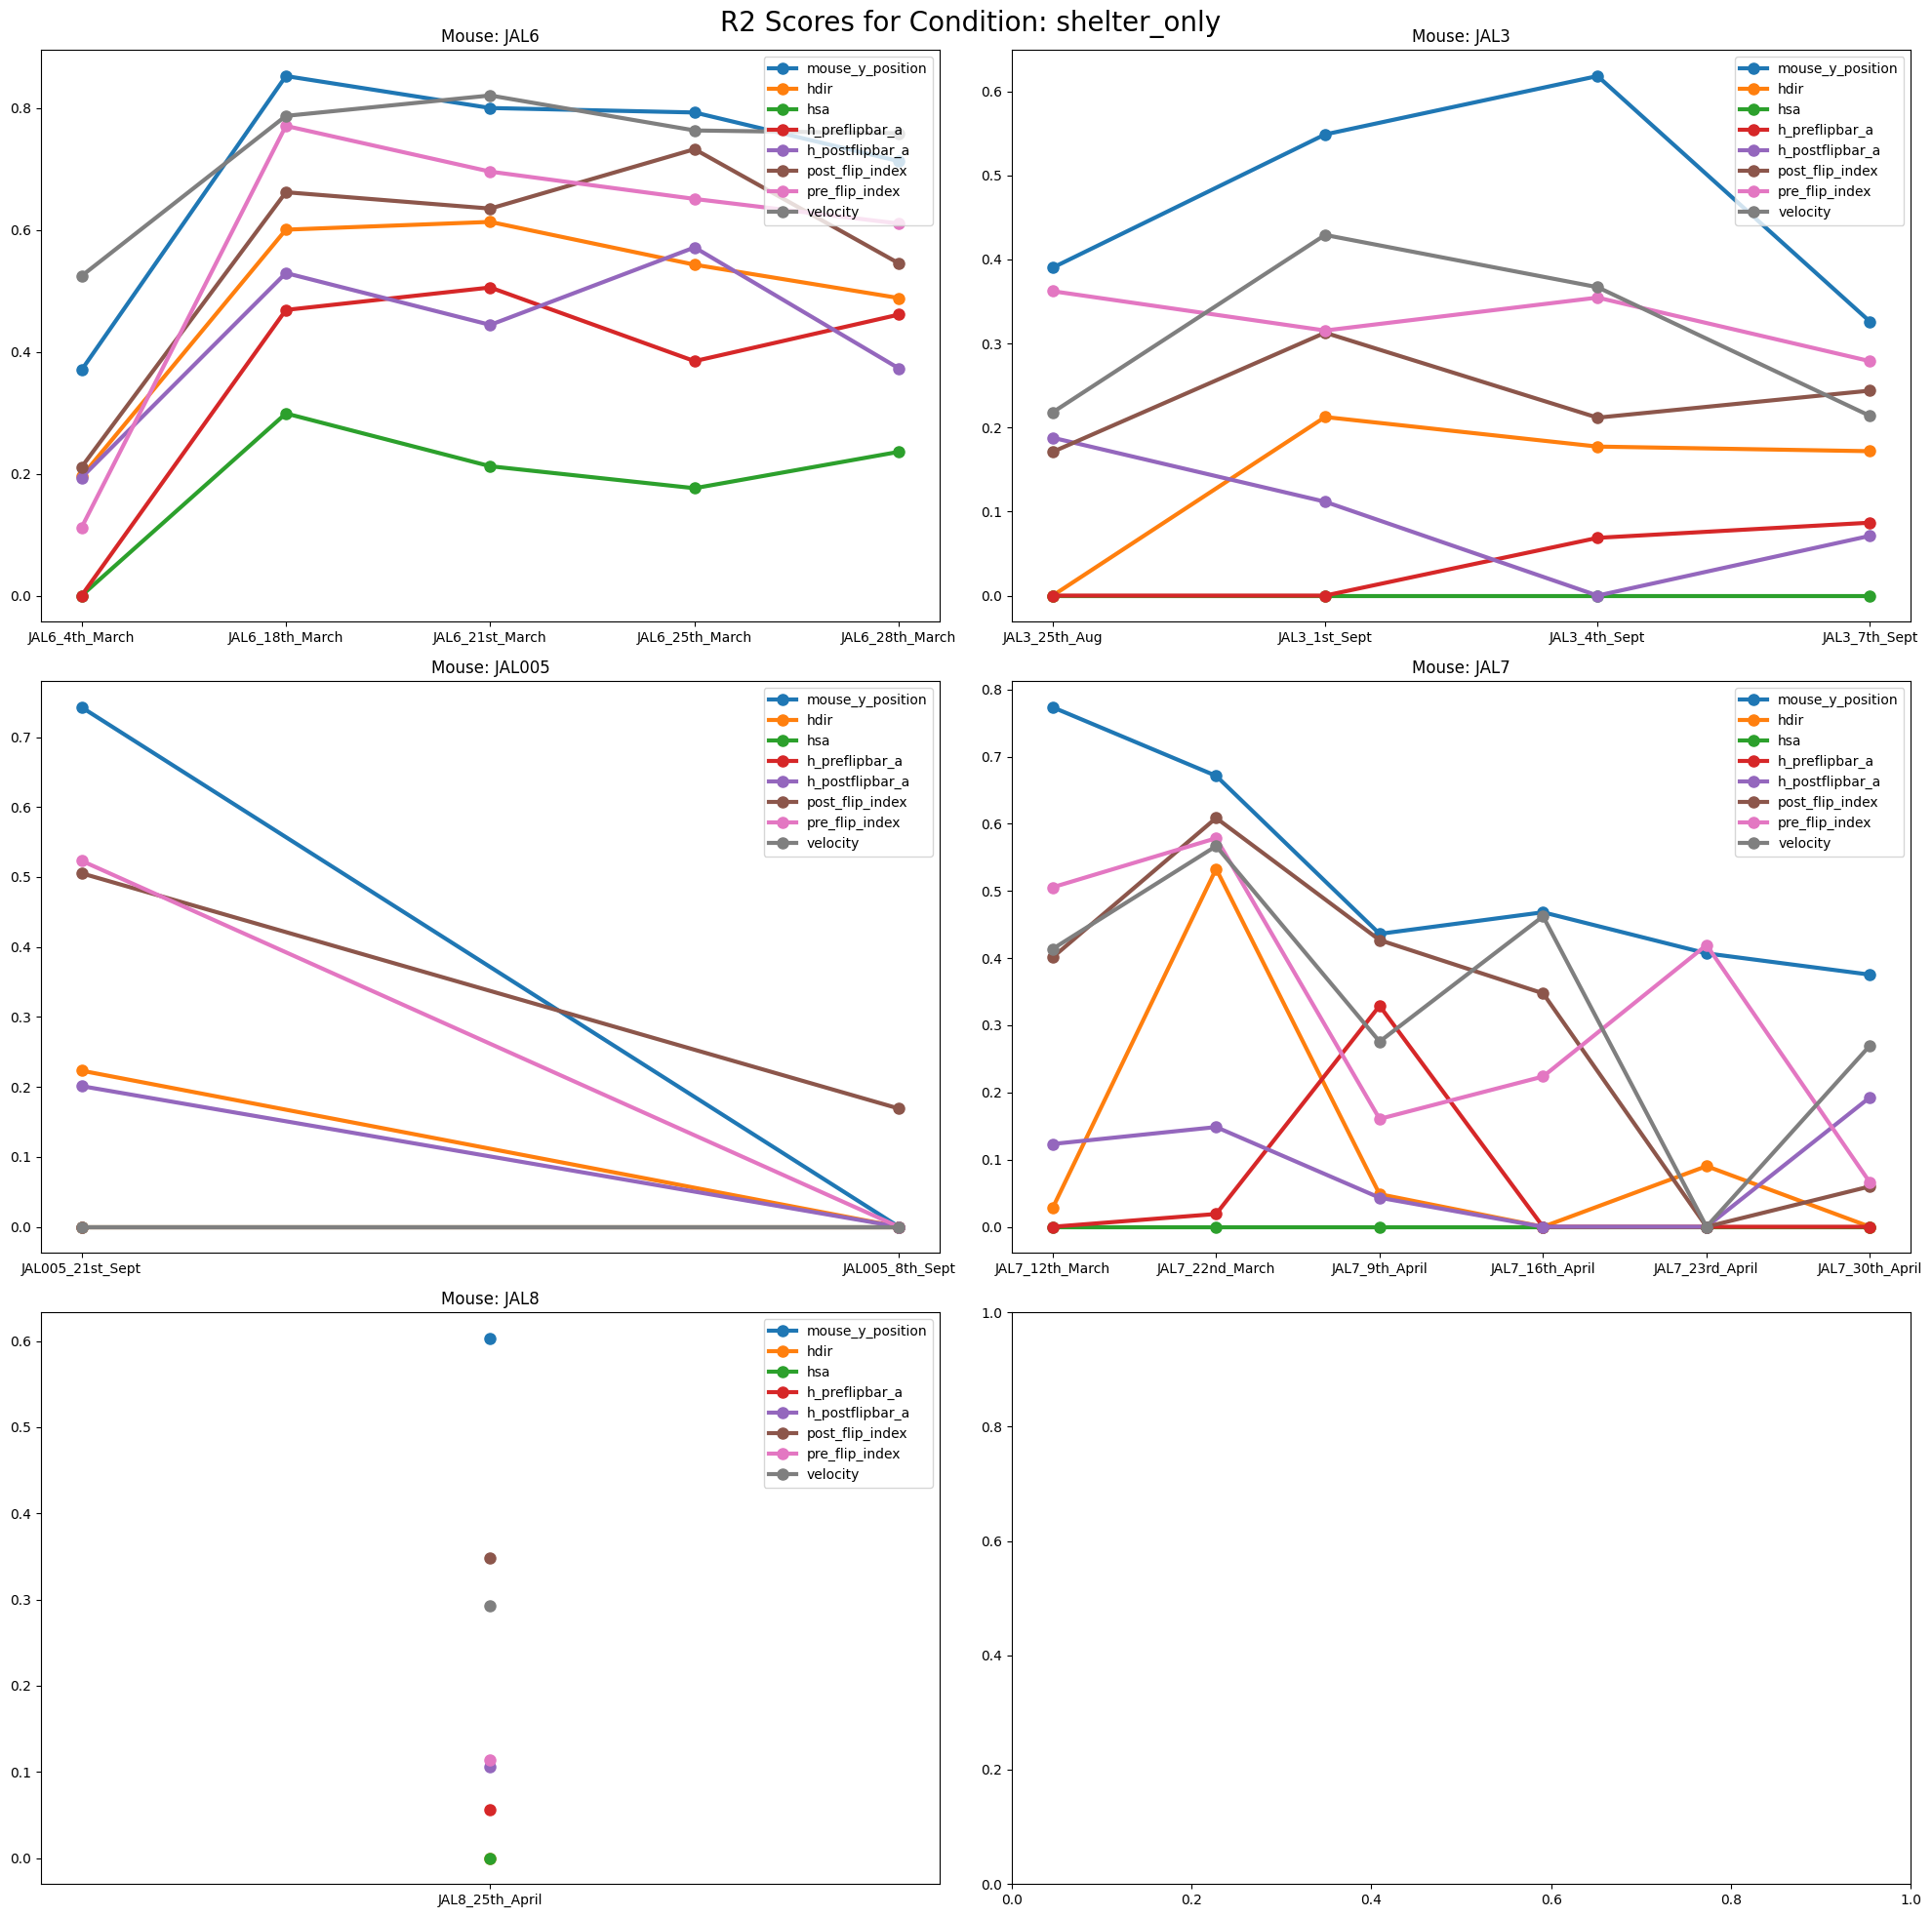

Plotting mouse: JAL6
Plotting mouse: JAL3
Plotting mouse: JAL005
Plotting mouse: JAL7
Plotting mouse: JAL8


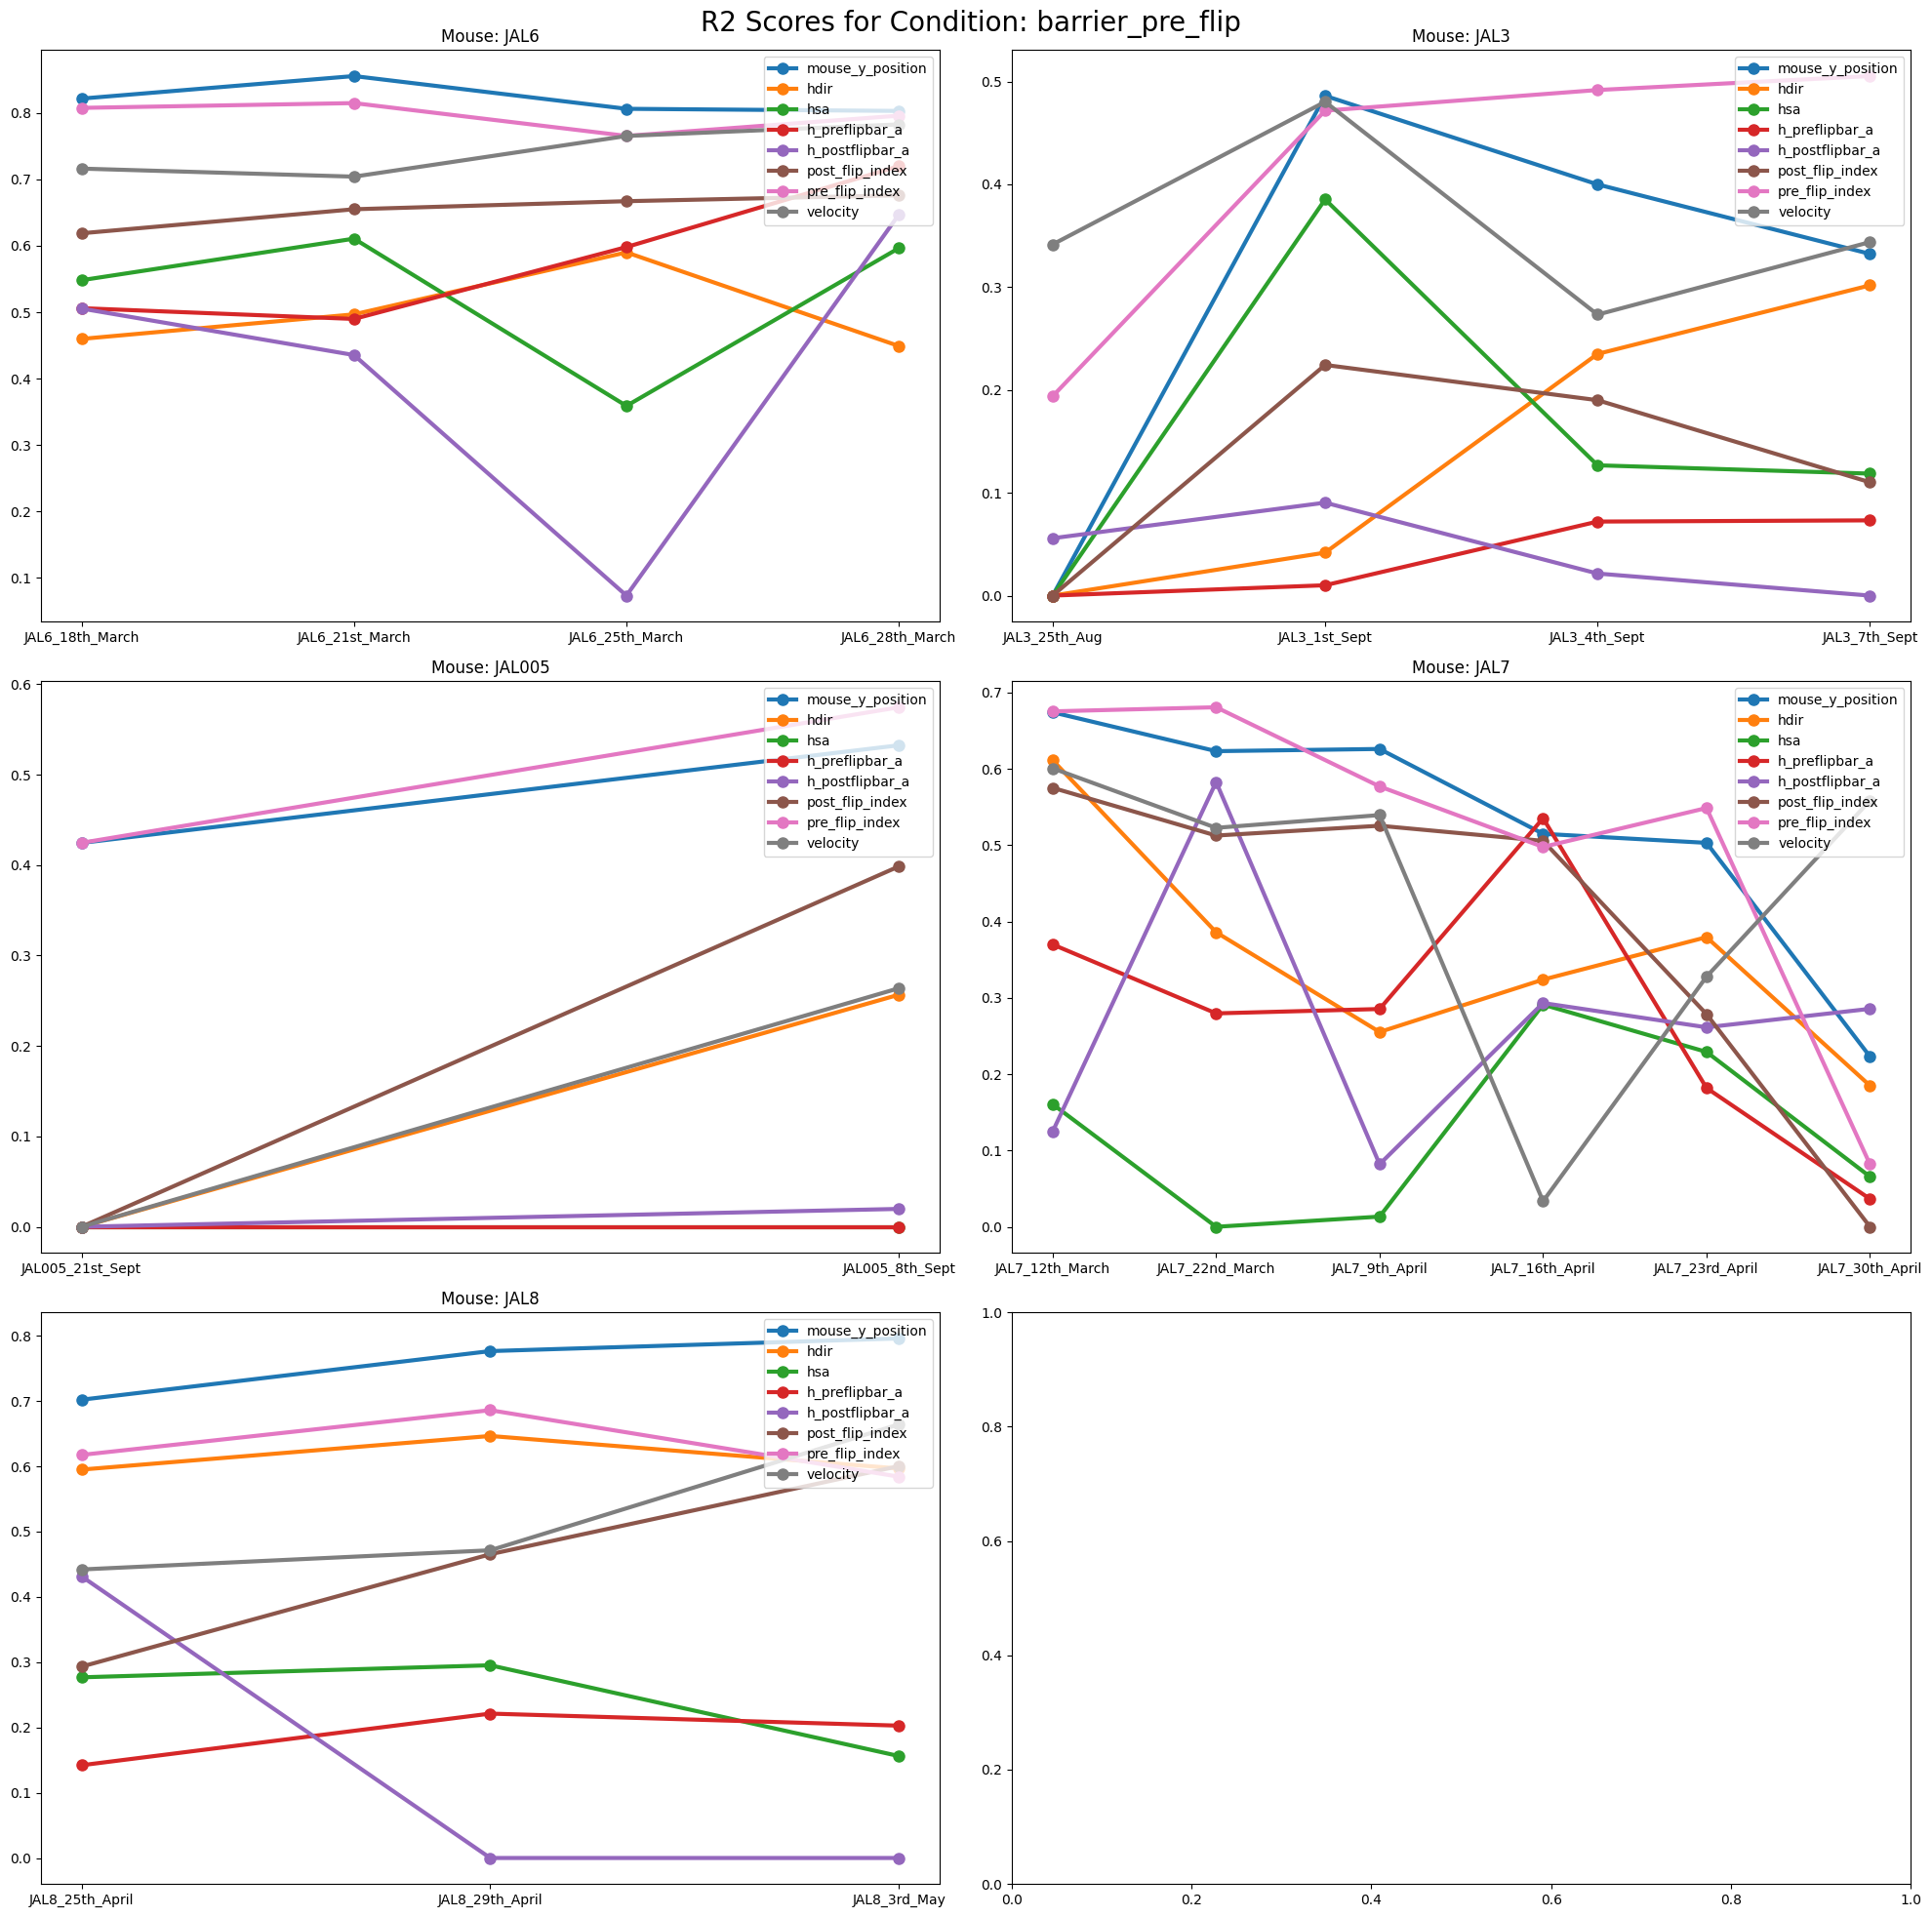

Plotting mouse: JAL6
Plotting mouse: JAL3
Plotting mouse: JAL005
Plotting mouse: JAL7
Plotting mouse: JAL8


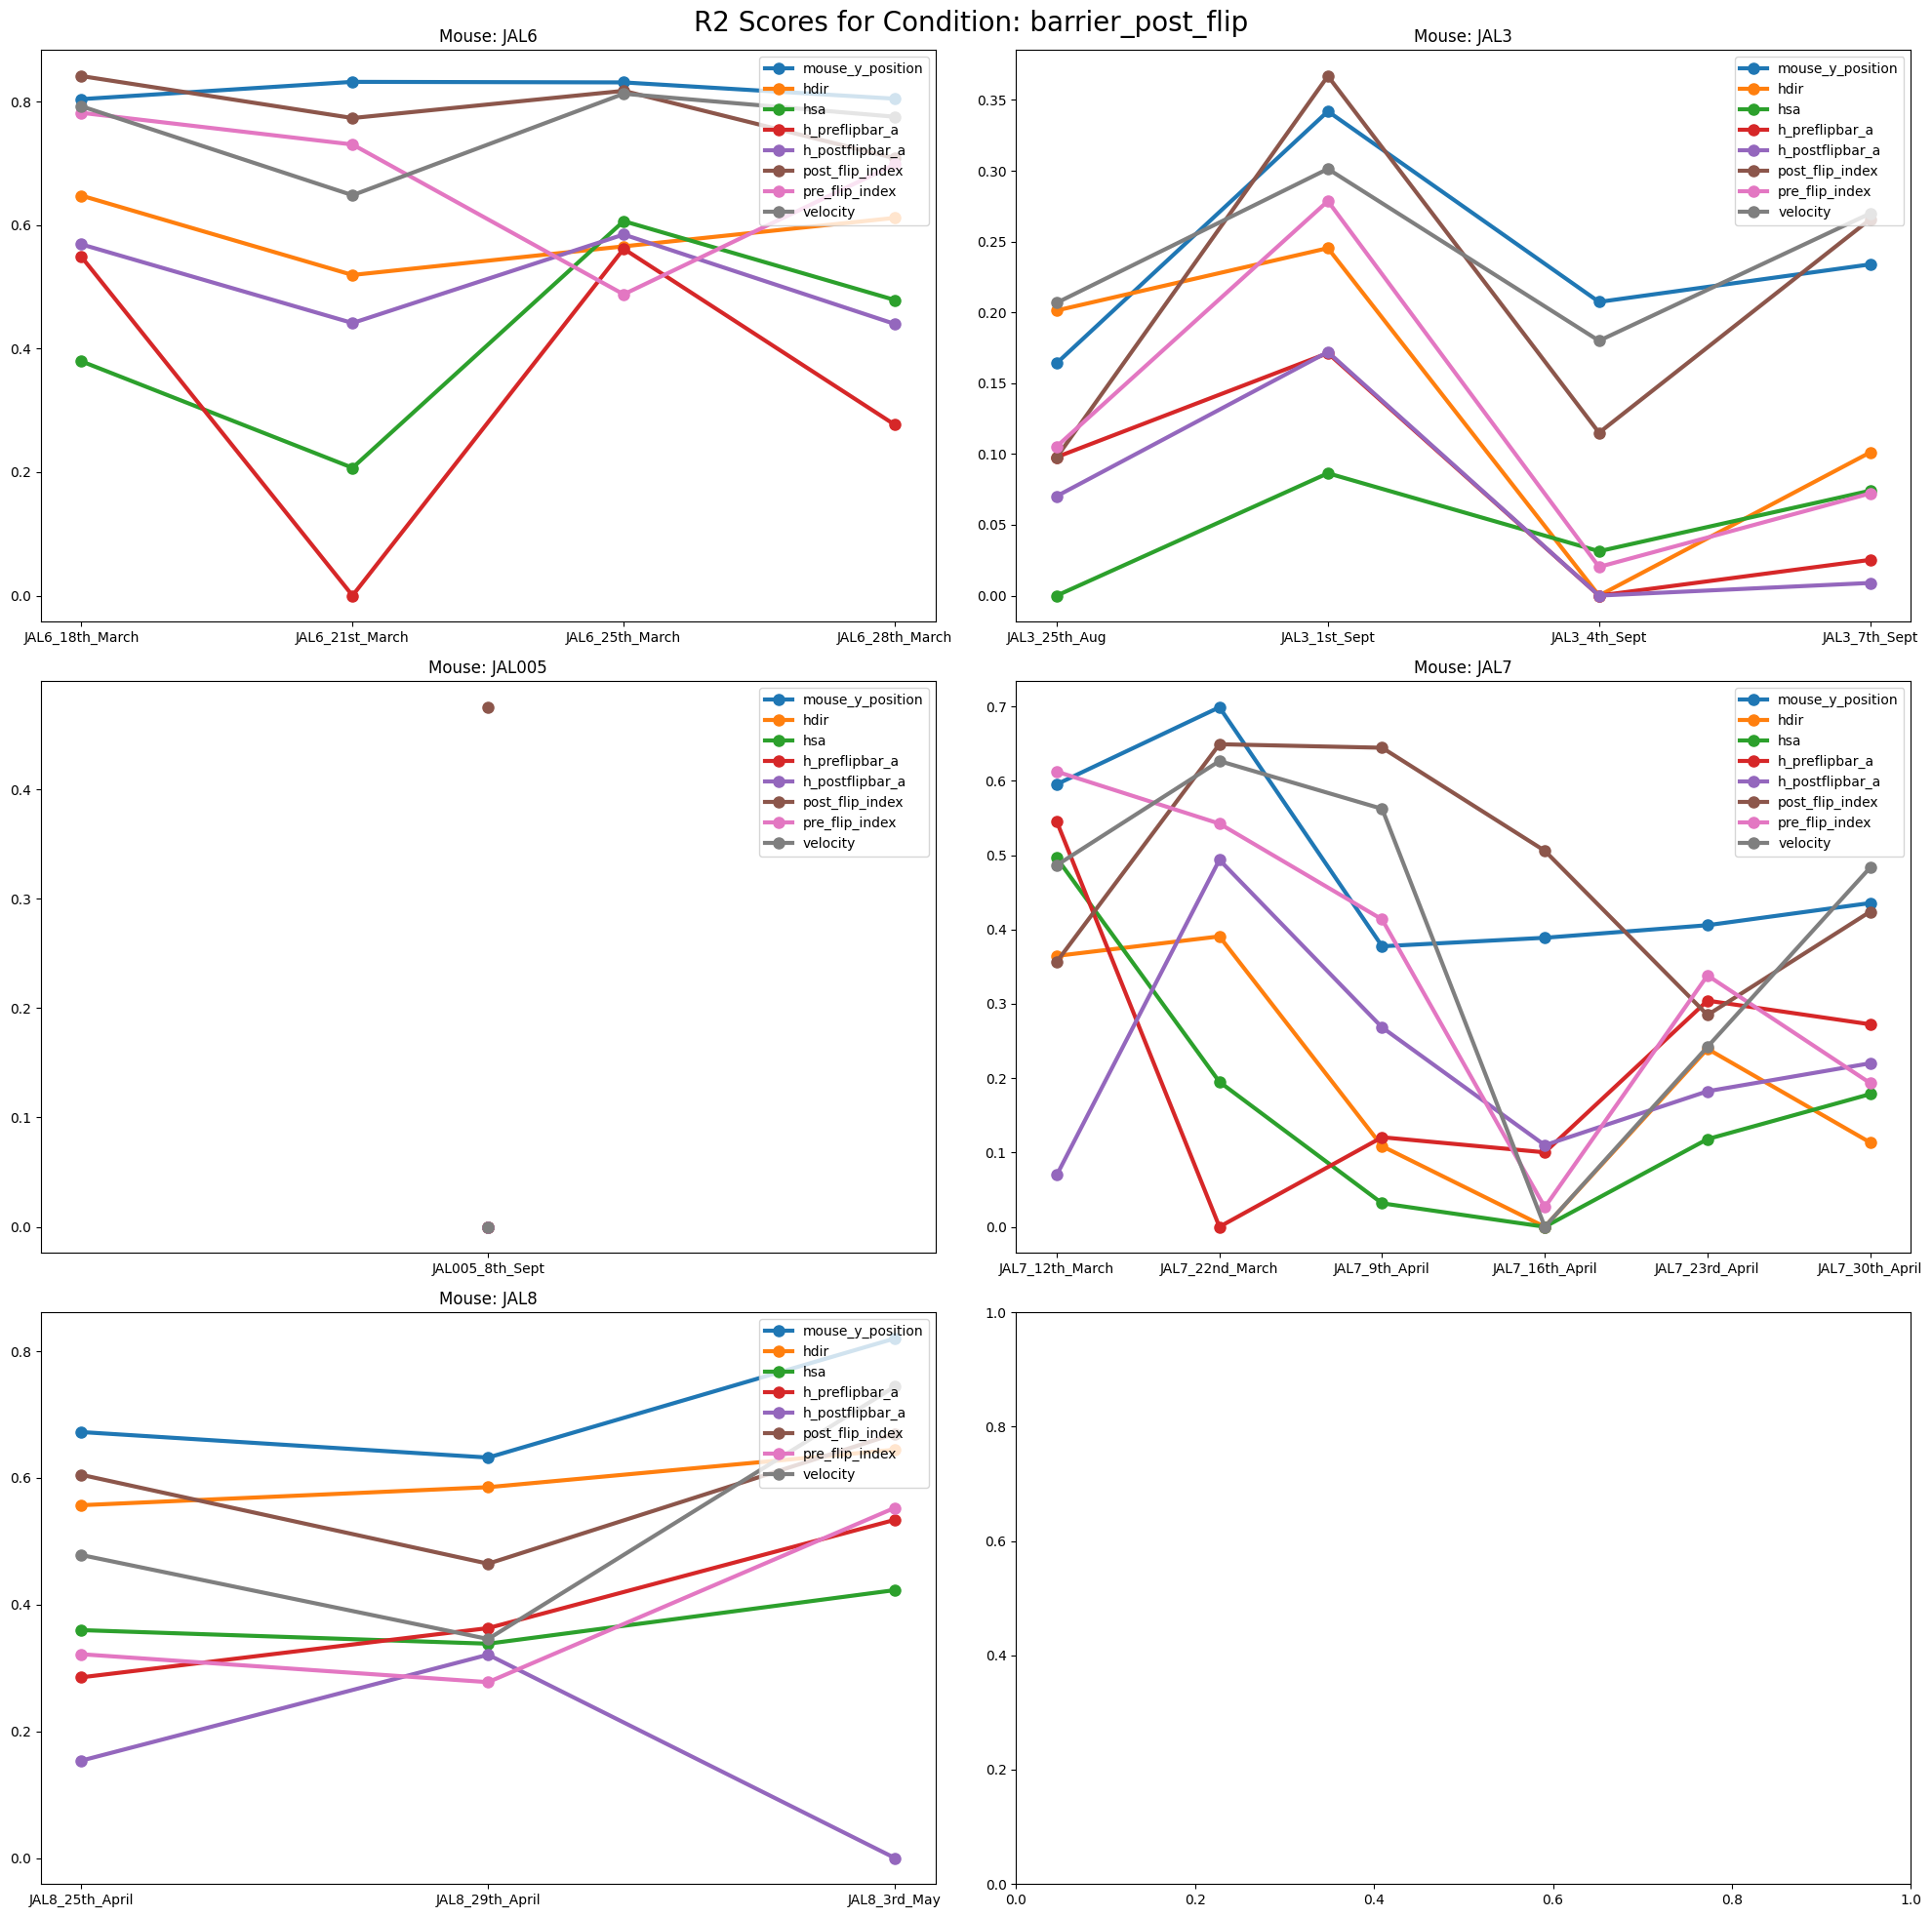

In [150]:
def plot_mice_on_separate_axes(con_dict, conditions, mice_names):
    for condition in conditions:
        df = con_dict[condition]
        # remove columns from df
        df = df.drop(columns=["frames", "homing_id", "mouse_x_position", "random"])
        
        df[df < 0] = 0  # Clip negative values to zero

        # Create a 3x2 grid of subplots (adjust based on how many mice there are)
        fig, axs = plt.subplots(3, 2, figsize=(20, 20))
        fig.suptitle(f"R2 Scores for Condition: {condition}", fontsize=20)

        row_idx = 0
        col_idx = 0
        
        for mouse in mice_names:
            
            # Check if you need to move to the next row after filling the current column
            if col_idx == 2:
                row_idx += 1
                col_idx = 0  # Reset column index after completing a row

            # Check if we have more rows than subplot grid size, adjust accordingly
            if row_idx == 3:
                print("Warning: Too many mice for the grid size, skipping extra mice.")
                break
            
            print(f"Plotting mouse: {mouse}")
            mouse_data = df[df.index.str.contains(mouse)]
            
            if mouse == "JAL6":
                # Set the index as a Categorical type with the specified order
                mouse_data.index = pd.Categorical(mouse_data.index, categories=JAL6_session_order, ordered=True)
                mouse_data = mouse_data.sort_index()
            
            if mouse == "JAL3":
                # Set the index as a Categorical type with the specified order
                mouse_data.index = pd.Categorical(mouse_data.index, categories=JAL3_session_order, ordered=True)
                mouse_data = mouse_data.sort_index()
            
            if mouse == "JAL7":
                # Set the index as a Categorical type with the specified order
                mouse_data.index = pd.Categorical(mouse_data.index, categories=JAL7_session_order, ordered=True)
                mouse_data = mouse_data.sort_index()

            # Plot each column (data series) for the current mouse
            for column in mouse_data.columns:
                axs[row_idx, col_idx].plot(mouse_data[column], marker='o', label=column, linewidth=3, markersize=8)
                axs[row_idx, col_idx].set_title(f'Mouse: {mouse}')
                
            axs[row_idx, col_idx].legend(loc="upper right")

            col_idx += 1  # Move to the next column for the next mouse

        # Adjust layout to prevent overlap
        plt.tight_layout()
        plt.show()

# Example usage
plot_mice_on_separate_axes(con_dict, conditions, mice_names)
